pca.n_components_ = 8
Original number of features: 8
PCA created 8 components

range(pca.n_components_) = [0, 1, 2, 3, 4, 5, 6, 7]



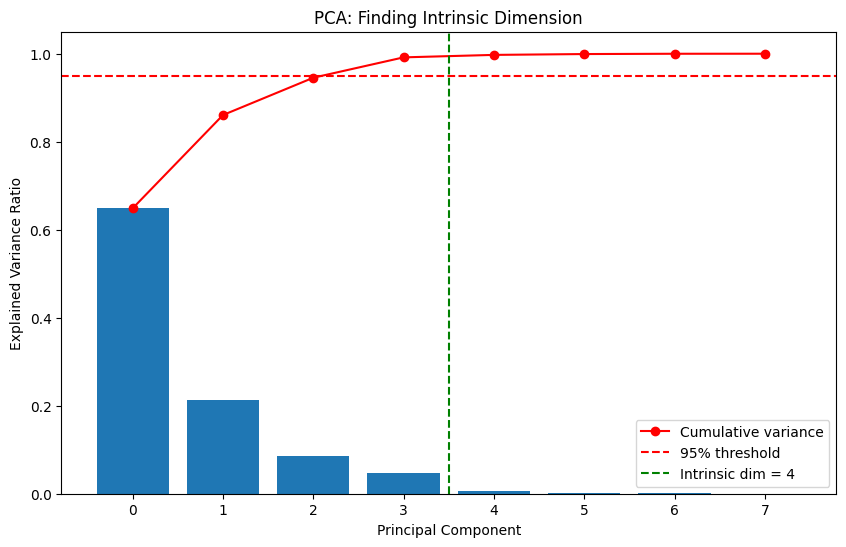

EXPLANATION:
  - You have 8 features
  - PCA created 8 components
  - First 4 components explain 95% of variance
  - Intrinsic dimension ≈ 4


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

features = pd.read_csv("seeds.csv")

# Scale the data
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply PCA
pca = PCA()
pca.fit(features_scaled)

# Create features for x-axis (0 to n_components_-1)
features_range = range(pca.n_components_)
print(f"range(pca.n_components_) = {list(features_range)}\n")

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.bar(features_range, pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA: Finding Intrinsic Dimension')
plt.xticks(features_range)

# Find intrinsic dimension (where cumulative variance reaches 95%)
cumulative = np.cumsum(pca.explained_variance_ratio_)
intrinsic_dim = np.argmax(cumulative >= 0.95) + 1

# Add cumulative line
plt.plot(features_range, cumulative, 'ro-', label='Cumulative variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.axvline(x=intrinsic_dim-0.5, color='g', linestyle='--', label=f'Intrinsic dim = {intrinsic_dim}')

plt.legend()
plt.show()

print(f"EXPLANATION:")
print(f"  - You have {features.shape[1]} features")
print(f"  - PCA created {pca.n_components_} components")
print(f"  - First {intrinsic_dim} components explain 95% of variance")
print(f"  - Intrinsic dimension ≈ {intrinsic_dim}")

Components shape: (8, 8)
Number of components: 8
PC1 variance: 64.84%
PC2 variance: 21.22%
PC3 variance: 8.49%
PC4 variance: 4.62%
Cumulative variance (PC1-PC4): 99.17%


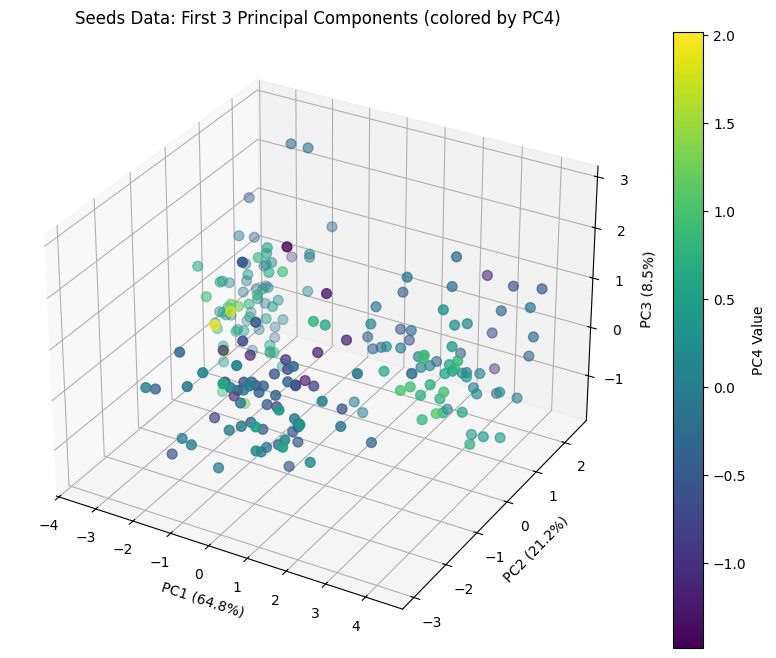

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Load data (using your seeds.csv file)
X = pd.read_csv("seeds.csv", header=None)  

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA
model = PCA()
model.fit(X_scaled)

# Get components (first 4 since intrinsic dimension = 4)
pc1 = model.components_[0, :]
pc2 = model.components_[1, :]
pc3 = model.components_[2, :]
pc4 = model.components_[3, :]

print("Components shape:", model.components_.shape)
print(f"Number of components: {len(model.components_)}")
print(f"PC1 variance: {model.explained_variance_ratio_[0]:.2%}")
print(f"PC2 variance: {model.explained_variance_ratio_[1]:.2%}")
print(f"PC3 variance: {model.explained_variance_ratio_[2]:.2%}")
print(f"PC4 variance: {model.explained_variance_ratio_[3]:.2%}")
print(f"Cumulative variance (PC1-PC4): {sum(model.explained_variance_ratio_[:4]):.2%}")

# 3D visualization of first 3 components (can't visualize 4D easily)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Transform data to PC space
X_pca = model.transform(X_scaled)

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], 
                     c=X_pca[:, 3], cmap='viridis', s=50)  # Color by PC4 values

ax.set_xlabel(f'PC1 ({model.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({model.explained_variance_ratio_[1]:.1%})')
ax.set_zlabel(f'PC3 ({model.explained_variance_ratio_[2]:.1%})')
ax.set_title('Seeds Data: First 3 Principal Components (colored by PC4)')
plt.colorbar(scatter, label='PC4 Value')
plt.show()